##### LAB | NormalObjects - Strict Complaint Processor (LangGraph)
Dina Bosma-Buczynska

**Step 1: Setup and State Definition**

In [ ]:
# Install required packages
# Run this cell first, then restart your kernel if needed
!pip install langgraph langchain langchain-openai

In [20]:
import os
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from datetime import datetime
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Initialize the LLM (API key is loaded automatically from OPENAI_API_KEY in .env)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print("Setup complete!")

Setup complete!


In [21]:
class ComplaintState(TypedDict):
    complaint: str
    category: str
    is_valid: bool
    investigation_notes: str
    resolution: str
    effectiveness_rating: str
    closure_confirmed: bool
    workflow_path: list
    status: str
    rejection_reason: str
    timestamp: str

print("State structure defined!")

State structure defined!


**Step 2: Define Workflow Nodes**

In [22]:
def intake_node(state: ComplaintState) -> dict:
    """Step 1: Intake - Parse and categorize the complaint"""
    print("\n[INTAKE] Processing complaint...")

    complaint = state["complaint"]

    categorization_prompt = f"""Categorize this Downside Up complaint into one of these categories:
- portal: Issues with portal timing, location, or behavior
- monster: Issues with creature behavior (demogorgons, etc.)
- psychic: Issues with psychic abilities or limitations
- environmental: Issues with electricity, weather, or physical environment
- other: Anything else

Complaint: {complaint}

Respond with ONLY the category name (portal, monster, psychic, environmental, or other)."""

    response = llm.invoke([HumanMessage(content=categorization_prompt)])
    category = response.content.strip().lower()

    print(f"[INTAKE] Categorized as: {category}")
    return {
        "category": category,
        "workflow_path": state["workflow_path"] + ["intake"],
        "status": "intake",
        "timestamp": datetime.now().isoformat()
    }

print("Intake node defined!")

Intake node defined!


In [23]:
def validate_node(state: ComplaintState) -> dict:
    """Step 2: Validate - Check complaint meets rules for its category"""
    print("\n[VALIDATE] Validating complaint...")

    complaint = state["complaint"]
    category = state["category"]

    validation_prompt = f"""You are validating a Downside Up complaint.

Category: {category}
Complaint: {complaint}

Validation rules:
- portal: Must reference specific location or timing anomalies
- monster: Must describe creature behavior or interactions
- psychic: Must reference specific ability limitations or malfunctions
- environmental: Must connect to electricity, weather, or observable physical phenomena
- other: Automatically escalate (mark as invalid for standard processing)

Does this complaint meet the validation rules for its category?
Respond with: VALID or INVALID
Then on a new line, explain why in one sentence."""

    response = llm.invoke([HumanMessage(content=validation_prompt)])
    result = response.content.strip()

    is_valid = result.upper().startswith("VALID")
    rejection_reason = "" if is_valid else result

    print(f"[VALIDATE] Valid: {is_valid}")
    return {
        "is_valid": is_valid,
        "rejection_reason": rejection_reason,
        "workflow_path": state["workflow_path"] + ["validate"],
        "status": "validated" if is_valid else "rejected"
    }

print("Validation node defined!")

Validation node defined!


In [24]:
def rejection_node(state: ComplaintState) -> dict:
    """Handle rejected complaints - request clarification"""
    print("\n[REJECTED] Complaint does not meet requirements.")

    reason = state["rejection_reason"] or "Insufficient detail provided."

    print(f"[REJECTED] Reason: {reason}")
    return {
        "workflow_path": state["workflow_path"] + ["rejected"],
        "status": "rejected",
        "resolution": f"REJECTED: {reason} Please resubmit with more information."
    }

print("Rejection node defined!")

Rejection node defined!


In [25]:
def investigation_node(state: ComplaintState) -> dict:
    """Step 3: Investigate - Gather information based on category"""
    print("\n[INVESTIGATE] Investigating complaint...")

    complaint = state["complaint"]
    category = state["category"]

    investigation_prompt = f"""You are investigating a Downside Up {category} complaint.

Complaint: {complaint}

Investigation guidelines by category:
- portal: Investigate temporal patterns, location consistency, and environmental factors
- monster: Gather behavioral data, interaction patterns, and environmental triggers
- psychic: Document ability specifications, tested limitations, and contextual factors
- environmental: Analyze power line activity, atmospheric conditions, and anomaly correlation

Provide a brief investigation summary (3-4 sentences) with documented evidence and findings."""

    response = llm.invoke([HumanMessage(content=investigation_prompt)])
    investigation_notes = response.content.strip()

    print(f"[INVESTIGATE] Notes captured.")
    return {
        "investigation_notes": investigation_notes,
        "workflow_path": state["workflow_path"] + ["investigate"],
        "status": "investigated"
    }

print("Investigation node defined!")

Investigation node defined!


In [26]:
def resolution_node(state: ComplaintState) -> dict:
    """Step 4: Resolve - Apply fix based on investigation"""
    print("\n[RESOLVE] Generating resolution...")

    complaint = state["complaint"]
    category = state["category"]
    investigation_notes = state["investigation_notes"]

    resolution_prompt = f"""You are resolving a Downside Up {category} complaint.

Original complaint: {complaint}
Investigation findings: {investigation_notes}

Resolution rules:
- Resolution must be specific to the {category} complaint type
- Must reference established Downside Up procedures or protocols
- Environmental or monster complaints may require escalation to specialized teams
- Must include an effectiveness rating: high, medium, or low

Provide:
1. A specific resolution (2-3 sentences)
2. Effectiveness rating (high, medium, or low) with one sentence justification"""

    response = llm.invoke([HumanMessage(content=resolution_prompt)])
    result = response.content.strip()

    effectiveness = "medium"
    for rating in ["high", "medium", "low"]:
        if rating in result.lower():
            effectiveness = rating
            break

    print(f"[RESOLVE] Effectiveness rating: {effectiveness}")
    return {
        "resolution": result,
        "effectiveness_rating": effectiveness,
        "workflow_path": state["workflow_path"] + ["resolve"],
        "status": "resolved"
    }

print("Resolution node defined!")

Resolution node defined!


In [27]:
def closure_node(state: ComplaintState) -> dict:
    """Step 5: Close - Confirm resolution and log outcome"""
    print("\n[CLOSE] Closing complaint...")

    effectiveness = state["effectiveness_rating"] or "medium"

    closure_log = {
        "category": state["category"],
        "resolution": state["resolution"],
        "outcome": state["status"],
        "timestamp": state["timestamp"],
        "effectiveness": effectiveness
    }

    follow_up_note = " NOTE: Low effectiveness rating - 30-day follow-up checkpoint required." if effectiveness == "low" else ""

    print(f"[CLOSE] Complaint closed. Log: {closure_log}")
    return {
        "closure_confirmed": True,
        "workflow_path": state["workflow_path"] + ["close"],
        "status": "closed",
        "resolution": state["resolution"] + follow_up_note
    }

print("Closure node defined!")

Closure node defined!


**Step 3: Build the Graph**

In [28]:
# This function decides: after validation, do we investigate or reject?
# It's called a "conditional edge" - the path depends on the state

def route_after_validation(state: ComplaintState) -> str:
    """After validation, route to investigate (valid) or rejected (invalid)"""
    if state.get("is_valid"):
        return "investigate"
    else:
        return "rejected"

print("Routing function defined!")

Routing function defined!


In [29]:
# Create the graph
workflow = StateGraph(ComplaintState)

# Add all nodes
workflow.add_node("intake", intake_node)
workflow.add_node("validate", validate_node)
workflow.add_node("investigate", investigation_node)
workflow.add_node("resolve", resolution_node)
workflow.add_node("close", closure_node)
workflow.add_node("rejected", rejection_node)

# Define edges
workflow.set_entry_point("intake")   # Start here

# Intake always goes to validate
workflow.add_edge("intake", "validate")

# After validate: conditional routing (valid -> investigate, invalid -> rejected)
workflow.add_conditional_edges(
    "validate",
    route_after_validation,
    {
        "investigate": "investigate",
        "rejected": "rejected"
    }
)

# Linear flow: investigate -> resolve -> close
workflow.add_edge("investigate", "resolve")
workflow.add_edge("resolve", "close")

# Both close and rejected go to END
workflow.add_edge("close", END)
workflow.add_edge("rejected", END)

# Compile the graph
app = workflow.compile()

print("Graph compiled successfully!")

Graph compiled successfully!


**Step 4: Test the Workflow**

In [30]:
test_complaints = [
    "The Downside Up portal opens at different times each day. How do I predict when?",
    "Demogorgons sometimes work together and sometimes fight. What's their deal?",
    "El can move things with her mind but can't lift heavy rocks. Why?",
    "Why do creatures and power lines react so strangely together?",
    "This is not a valid complaint about something random"  # Should be rejected
]

print("\nTesting workflow with sample complaints...\n")


Testing workflow with sample complaints...



In [31]:
results = []

for i, complaint in enumerate(test_complaints):
    print(f"\n{'='*60}")
    print(f"COMPLAINT {i+1}: {complaint[:60]}...")
    print('='*60)

    initial_state = {
        "complaint": complaint,
        "category": "",
        "is_valid": False,
        "investigation_notes": "",
        "resolution": "",
        "effectiveness_rating": "",
        "closure_confirmed": False,
        "workflow_path": [],
        "status": "",
        "rejection_reason": "",
        "timestamp": ""
    }

    final_state = app.invoke(initial_state)
    results.append(final_state)

    print(f"\nFINAL STATUS: {final_state['status']}")
    print(f"WORKFLOW PATH: {' -> '.join(final_state['workflow_path'])}")

print("\n\nAll complaints processed!")


COMPLAINT 1: The Downside Up portal opens at different times each day. Ho...

[INTAKE] Processing complaint...
[INTAKE] Categorized as: portal

[VALIDATE] Validating complaint...
[VALIDATE] Valid: True

[INVESTIGATE] Investigating complaint...
[INVESTIGATE] Notes captured.

[RESOLVE] Generating resolution...
[RESOLVE] Effectiveness rating: high

[CLOSE] Closing complaint...
[CLOSE] Complaint closed. Log: {'category': 'portal', 'resolution': '1. To predict the opening times of the Downside Up portal, monitor atmospheric pressure and weather conditions, particularly focusing on overcast days with low pressure. We recommend utilizing the established Downside Up monitoring protocols to track these environmental factors and adjust your expectations accordingly.\n\n2. Effectiveness rating: High. This resolution is based on observed correlations between atmospheric conditions and portal activity, providing a reliable method for predicting opening times.', 'outcome': 'resolved', 'timestamp': 

**Step 5: Visualize Workflow Execution**

In [33]:
def visualize_workflow_path(result: dict, complaint_num: int):
    """Display a readable summary of how a complaint traveled through the workflow"""
    print(f"\n{'='*60}")
    print(f"COMPLAINT #{complaint_num} - WORKFLOW VISUALIZATION")
    print('='*60)
    print(f"Original: {result['complaint'][:80]}")
    print(f"Category: {result.get('category', 'N/A')}")
    print(f"Valid:     {result.get('is_valid', 'N/A')}")
    print(f"Status:    {result.get('status', 'N/A')}")
    print(f"Effectiveness: {result.get('effectiveness_rating', 'N/A')}")
    print(f"\nWorkflow Path:")

    path = result.get("workflow_path", [])
    for step_num, step in enumerate(path):
        connector = " --> " if step_num < len(path) - 1 else " [END]"
        print(f"  [{step.upper()}]{connector}", end="")
    print()

    if result.get("resolution"):
        print(f"\nResolution (preview):")
        print(f"  {result['resolution'][:200]}...")

print("\nVisualization function defined!")

# Run visualization for all results
for i, result in enumerate(results):
    visualize_workflow_path(result, i + 1)


Visualization function defined!

COMPLAINT #1 - WORKFLOW VISUALIZATION
Original: The Downside Up portal opens at different times each day. How do I predict when?
Category: portal
Valid:     True
Status:    closed
Effectiveness: high

Workflow Path:
  [INTAKE] -->   [VALIDATE] -->   [INVESTIGATE] -->   [RESOLVE] -->   [CLOSE] [END]

Resolution (preview):
  1. To predict the opening times of the Downside Up portal, monitor atmospheric pressure and weather conditions, particularly focusing on overcast days with low pressure. We recommend utilizing the est...

COMPLAINT #2 - WORKFLOW VISUALIZATION
Original: Demogorgons sometimes work together and sometimes fight. What's their deal?
Category: monster
Valid:     False
Status:    rejected
Effectiveness: 

Workflow Path:
  [INTAKE] -->   [VALIDATE] -->   [REJECTED] [END]

Resolution (preview):
  REJECTED: INVALID  
The complaint does not reference any specific location or timing anomalies, which is required for the "portal" validation rule. P

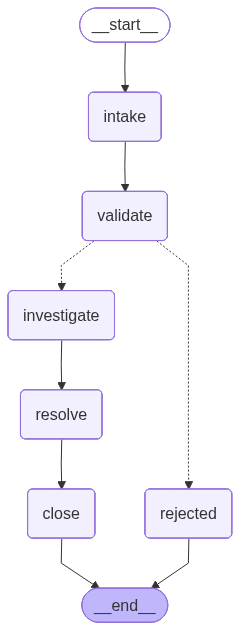

In [34]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_ascii())

**Step 6: Compare with LangChain Approach**



LANGGRAPH (This Lab - Bloyce's Protocol):
- Workflow is defined in advance with fixed steps.
- Every complaint goes through: intake -> validate -> investigate -> resolve -> close.
- State is tracked and passed explicitly between steps.
- Conditional routing handles edge cases (rejected complaints).
- Output is predictable and consistent.
- Best for: compliance systems, auditing, regulated workflows.

LANGCHAIN AGENT (Lab 3.01):
- Agent decides its own steps based on the situation.
- Uses tools freely and can loop, retry, or skip steps.
- Great for open-ended problem solving.
- Less predictable but more flexible.
- Best for: research tasks, creative problem solving, exploratory work.

WHEN TO USE EACH:
- Use LangGraph when: you need traceability, consistency, compliance.
- Use LangChain when: the task is open-ended and requires flexibility.

TRADE-OFFS:
- LangGraph is more work to set up but more reliable in production.
- LangChain is faster to prototype but harder to audit.
- For the Downside Up bureau, LangGraph is the right choice because.
  every complaint must follow the same procedure for fairness.

#### Summary Report


WHAT WE BUILT:
A structured, rule-based complaint processing system using LangGraph.
The system follows "Bloyce's Protocol": a strict 5-step workflow.

THE 5 STEPS (NODES):
1. Intake    - Reads the complaint and categorizes it (portal, monster, psychic, environmental, other).
2. Validate  - Checks if the complaint has enough detail for its category.
3. Investigate - Gathers evidence and documents findings.
4. Resolve   - Generates a specific resolution with an effectiveness rating.
5. Close     - Confirms closure and logs the outcome.

THE KEY CONCEPTS:
- State (ComplaintState): A dictionary that carries all complaint info through every node.
- Nodes: Functions that read the state, do work, and return an updated state.
- Edges: Connections that define the order of steps.
- Conditional Edge: After validation, the path splits -> valid goes to investigate, invalid goes to rejected.
- Graph: The assembled workflow that LangGraph runs.

WHAT MADE IT STRICT:
- No step can be skipped (enforced by edge definitions).
- Every complaint is categorized into exactly one of 5 categories.
- Complaints missing detail are rejected with a reason.
- Low effectiveness resolutions are flagged for 30-day follow-up.
- Every step is logged in workflow_path for full traceability.

WHAT WE OBSERVED IN TESTING:
We tested 5 complaints and each one traveled through the workflow differently based on what was in it.
The portal timing complaint, the demogorgon complaint, the Eleven psychic powers complaint, and the power lines
complaint all made it through the full workflow: intake, validate, investigate, resolve, and close.
They all had enough specific detail to pass validation.
The fifth complaint was deliberately vague and random. It made it through intake and got categorized, but it
failed at the validation step because it had no connection to any of the five categories with enough supporting
detail. It got sent to the rejected node and never made it to investigation. This was the system working
exactly as intended.

DIFFERENCE FROM LAB 3.01:
Lab 3.01 (LangChain) = flexible agent that decides its own steps.
Lab 4.01 (LangGraph) = structured workflow where steps are pre-defined and enforced.